
 1  **Entity Clustering**  Common-input-ownership heuristic + graph embeddings, evaluated against`wallets.csv.entity_id` 

 2  **Anomaly Detection**  Isolation Forest over engineered transaction features, evaluated against `labels.csv.is_anomaly` 

 3  **Peeling-Chain / Mixing Detection**  Structural graph features (chain depth, fan-out) + a classifier over `pattern_type` 

 4  **Risk Scoring**  Personalized PageRank propagation from `seed_illicit_wallets.csv`, evaluated against `wallets.csv.is_illicit` 


## 0. Setup & imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score, homogeneity_completeness_v_measure,
    roc_auc_score, average_precision_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve,
)

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

pd.set_option("display.max_columns", 50)
np.random.seed(42)

_candidates = [Path("data"), Path("../data"), Path("../../data")]
DATA_DIR = next((c for c in _candidates if c.exists()), None)
assert DATA_DIR is not None, (
    "Can't find the data folder. Checked: " + ", ".join(str(c.resolve()) for c in _candidates) +
    " - make sure the 'data' folder (with transactions.csv etc.) sits directly inside your project folder."
)
DATA_DIR = DATA_DIR.resolve()
print("Using data folder:", DATA_DIR)


Using data folder: C:\Users\hp\OneDrive\Desktop\ML1\mlproject\project\data



## 1. Data ingestion & parsing

In [2]:
transactions = pd.read_csv(DATA_DIR / "transactions.csv")
tx_inputs    = pd.read_csv(DATA_DIR / "tx_inputs.csv")
tx_outputs   = pd.read_csv(DATA_DIR / "tx_outputs.csv")
tx_edges     = pd.read_csv(DATA_DIR / "tx_edges.csv")
wallets      = pd.read_csv(DATA_DIR / "wallets.csv")
entities     = pd.read_csv(DATA_DIR / "entities.csv")
labels       = pd.read_csv(DATA_DIR / "labels.csv")
features     = pd.read_csv(DATA_DIR / "features.csv")
seed_illicit = pd.read_csv(DATA_DIR / "seed_illicit_wallets.csv")

print("transactions :", transactions.shape)
print("tx_inputs    :", tx_inputs.shape)
print("tx_outputs   :", tx_outputs.shape)
print("tx_edges     :", tx_edges.shape, " (money-flow graph: src_txid -> dst_txid)")
print("wallets      :", wallets.shape, " (ground truth entity_id / is_illicit)")
print("entities     :", entities.shape)
print("labels       :", labels.shape)
print("features     :", features.shape)
print("seed_illicit :", seed_illicit.shape, " (known-bad wallets, our propagation seed)")
transactions.head(3)


transactions : (50000, 16)
tx_inputs    : (115236, 3)
tx_outputs   : (93073, 3)
tx_edges     : (90268, 2)  (money-flow graph: src_txid -> dst_txid)
wallets      : (11695, 4)  (ground truth entity_id / is_illicit)
entities     : (3000, 4)
labels       : (50000, 7)
features     : (50000, 22)
seed_illicit : (46, 2)  (known-bad wallets, our propagation seed)


,txid,time_step,timestamp,src_ip,src_port,dst_ip,dst_port,geo_country,asn,asn_owner,num_inputs,num_outputs,total_input_btc,total_output_btc,fee_btc,script_type
0,1ca9a7276b425b81916ea4f7cbb378807113d3814e9fb1...,0,1580002576,219.103.100.88,36270,70.217.117.254,8333,SG,45102,ALIBABA-CN,5,10,0.263501,0.262921,0.000580,P2SH
1,8a46a675fb0355eaf25a9995c52b83abcbca680b0ecf1f...,0,1580003780,37.62.143.238,36684,110.71.174.216,8333,PA,62240,CLOUVIDER,1,2,0.051098,0.050960,0.000138,P2TR
2,f43fd014a5434130f983b7cd0e9ba6a70246b81fb6b4c2...,0,1580013012,68.116.26.150,54436,134.240.119.131,8333,AU,1221,TELSTRA,1,2,0.137021,0.136591,0.000430,P2PKH


In [3]:
with open(DATA_DIR / "sample_nested.json") as fh:
    nested = json.load(fh)

print(f"Loaded {len(nested)} nested transaction records from JSON.")
sample_tx = nested[0]
print(json.dumps(sample_tx, indent=2)[:900], "...")

def flatten_nested_tx(rec):
    base = {k: v for k, v in rec.items()
            if k not in ("input_addresses", "input_amounts", "output_addresses", "output_amounts")}
    ins = list(zip(rec["input_addresses"], rec["input_amounts"]))
    outs = list(zip(rec["output_addresses"], rec["output_amounts"]))
    return base, ins, outs

base, ins, outs = flatten_nested_tx(sample_tx)
print("\nParsed base fields:", base)
print("Parsed inputs :", ins[:3], "...")
print("Parsed outputs:", outs[:3], "...")


Loaded 1500 nested transaction records from JSON.
{
  "timestamp": 1580002576,
  "txid": "1ca9a7276b425b81916ea4f7cbb378807113d3814e9fb1cef0912e6dafacf4ee",
  "src_ip": "219.103.100.88",
  "src_port": 36270,
  "dst_ip": "70.217.117.254",
  "dst_port": 8333,
  "geo_country": "SG",
  "asn": 45102,
  "asn_owner": "ALIBABA-CN",
  "input_addresses": [
    "3k4auFAJWspLpCCFE23yAvr66zFCGvqC",
    "1TqGuPpK8fZXrsAoBrEFMANgcf3Nki5c",
    "1buAfjdbXKYar5ACuqKZgs3MRX3ZUW23",
    "bc1qa060edg6650exlyarvlvlz5h3xa2u70dhkv0t7",
    "3GsUFBEHL1iBFLc3b5dzD7KhCmLJNiFG"
  ],
  "input_amounts": [
    0.02397558,
    0.11400216,
    0.02021314,
    0.03766823,
    0.06764184
  ],
  "output_addresses": [
    "3k4auFAJWspLpCCFE23yAvr66zFCGvqC",
    "1rzVUhXejiTFuGMLN1TSgDxb8VMNhmtD",
    "1TqGuPpK8fZXrsAoBrEFMANgcf3Nki5c",
    "1TqGuPpK8fZXrsAoBrEFMANgcf3Nki5c",
    "1buAfjdbXKYar5ACuqKZgs3MRX3ZUW23",
    "1buAfjdbXKYar5ACuqKZgs3MRX3ZUW23",
    "bc1qa060edg66 ...

Parsed base fields: {'timestamp': 1580002576


## 2. Exploratory data audit

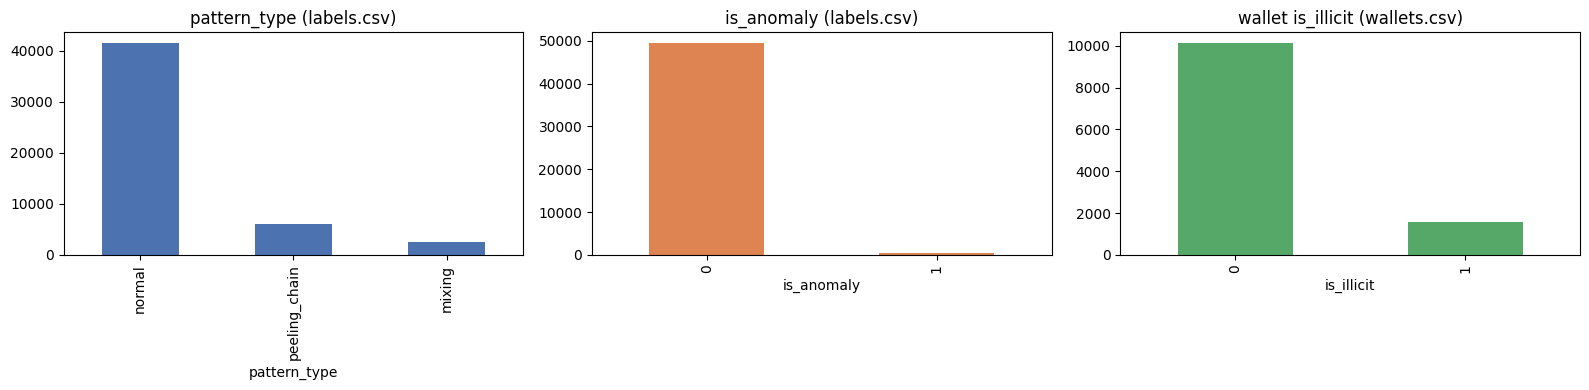

Illicit tx rate      : 0.2128
Illicit wallet rate  : 0.133
Anomaly rate         : 0.01


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

labels["pattern_type"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("pattern_type (labels.csv)")

labels["is_anomaly"].value_counts().plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("is_anomaly (labels.csv)")

wallets["is_illicit"].value_counts().plot(kind="bar", ax=axes[2], color="#55A868")
axes[2].set_title("wallet is_illicit (wallets.csv)")
plt.tight_layout(); plt.show()

print("Illicit tx rate      :", labels["is_illicit"].mean().round(4))
print("Illicit wallet rate  :", wallets["is_illicit"].mean().round(4))
print("Anomaly rate         :", labels["is_anomaly"].mean().round(4))


In [5]:
addr2ent = dict(zip(wallets["address"], wallets["entity_id"]))

grouped_in = tx_inputs.groupby("txid")["address"].apply(list)
multi_in = [a for a in grouped_in if len(a) > 1]
same = sum(1 for a in multi_in if len(set(addr2ent.get(x) for x in a)) == 1)
print(f"Multi-input transactions: {len(multi_in)}")
print(f"  -> same-entity inputs : {same}  ({same/len(multi_in):.2%})")
print(f"  -> mixed-entity inputs: {len(multi_in)-same}  ({1-same/len(multi_in):.2%})")


Multi-input transactions: 9212
  -> same-entity inputs : 17  (0.18%)
  -> mixed-entity inputs: 9195  (99.82%)



## 3. Entity Clustering

In [6]:
mixing_txids = set(labels.loc[labels.pattern_type == "mixing", "txid"])

addr_list = wallets["address"].tolist()
addr_idx = {a: i for i, a in enumerate(addr_list)}
parent = list(range(len(addr_list)))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(x, y):
    rx, ry = find(x), find(y)
    if rx != ry:
        parent[rx] = ry

grouped = tx_inputs[~tx_inputs.txid.isin(mixing_txids)].groupby("txid")["address"].apply(list)
for addrs in grouped:
    idxs = [addr_idx[a] for a in addrs if a in addr_idx]
    for i in range(1, len(idxs)):
        union(idxs[0], idxs[i])

common_input_cluster = np.array([find(i) for i in range(len(addr_list))])
print("Common-input clusters found:", len(set(common_input_cluster)))

true_entity = wallets["entity_id"].values
print("\n--- Common-input-only evaluation vs ground truth entity_id ---")
print("ARI :", adjusted_rand_score(true_entity, common_input_cluster))
print("NMI :", normalized_mutual_info_score(true_entity, common_input_cluster))
h, c, v = homogeneity_completeness_v_measure(true_entity, common_input_cluster)
print(f"Homogeneity: {h:.3f}  Completeness: {c:.3f}  V-measure: {v:.3f}")


Common-input clusters found: 1016

--- Common-input-only evaluation vs ground truth entity_id ---
ARI : -0.00016089937271033196
NMI : 0.12740855866951134
Homogeneity: 0.072  Completeness: 0.573  V-measure: 0.127


In [7]:
from scipy.sparse import coo_matrix

tx_id_list = sorted(set(tx_inputs.txid) | set(tx_outputs.txid))
tx_idx = {t: i for i, t in enumerate(tx_id_list)}

rows, cols = [], []
for _, r in pd.concat([tx_inputs[["txid", "address"]], tx_outputs[["txid", "address"]]]).iterrows():
    if r["address"] in addr_idx:
        rows.append(addr_idx[r["address"]]); cols.append(tx_idx[r["txid"]])

inc = coo_matrix((np.ones(len(rows)), (rows, cols)),
                  shape=(len(addr_list), len(tx_id_list))).tocsr()
print("Incidence matrix:", inc.shape, "nnz =", inc.nnz)

svd = TruncatedSVD(n_components=32, random_state=42)
addr_embeddings = svd.fit_transform(inc)
print("Embedding shape:", addr_embeddings.shape,
      "  explained variance:", svd.explained_variance_ratio_.sum().round(3))

kmeans = KMeans(n_clusters=3000, n_init=3, random_state=42)
embedding_cluster = kmeans.fit_predict(addr_embeddings)

print("\n--- Graph-embedding clustering evaluation vs ground truth entity_id ---")
print("ARI :", adjusted_rand_score(true_entity, embedding_cluster))
print("NMI :", normalized_mutual_info_score(true_entity, embedding_cluster))
h, c, v = homogeneity_completeness_v_measure(true_entity, embedding_cluster)
print(f"Homogeneity: {h:.3f}  Completeness: {c:.3f}  V-measure: {v:.3f}")


Incidence matrix: (11695, 50000) nnz = 190001
Embedding shape: (11695, 32)   explained variance: 0.018

--- Graph-embedding clustering evaluation vs ground truth entity_id ---
ARI : 0.03731080539260395
NMI : 0.6962644392231093
Homogeneity: 0.660  Completeness: 0.737  V-measure: 0.696


In [8]:
combo = pd.DataFrame({
    "address": addr_list,
    "common_input_cluster": common_input_cluster,
    "embedding_cluster": embedding_cluster,
    "true_entity": true_entity,
})
combo["predicted_entity_cluster"] = combo.groupby(
    ["embedding_cluster", "common_input_cluster"]
).ngroup()

print("--- Combined (embedding + common-input) clustering ---")
print("ARI :", adjusted_rand_score(combo.true_entity, combo.predicted_entity_cluster))
print("NMI :", normalized_mutual_info_score(combo.true_entity, combo.predicted_entity_cluster))
combo.head()


--- Combined (embedding + common-input) clustering ---
ARI : 0.010441524095103988
NMI : 0.7107187028861726


,address,common_input_cluster,embedding_cluster,true_entity,predicted_entity_cluster
0,12cDnimbTFVeJtx1qtBmUNJAEqN76R7P,2374,1425,0,2356
1,3yxQdDn53jFrK6wFx7RJWhvQBQPEjJmk,2374,1962,1,2907
2,3fhBboGBWRJhmcFkMvrr4Fu3tMSJ5Edy,2374,2391,1,3391
3,3EiYSyiWAH9GpcbHpeUzeSQF9ZY6q4x8,2374,2223,1,3178
4,1cx1ko8kybqJriN8KUBW1oyoHZqCZ7xh,2374,1744,2,2685


In [9]:
G = nx.DiGraph()
G.add_edges_from(zip(tx_edges.src_txid, tx_edges.dst_txid))
G.add_nodes_from(labels.txid.tolist())
indeg, outdeg = dict(G.in_degree()), dict(G.out_degree())

features["graph_indeg"] = features["txid"].map(indeg)
features["graph_outdeg"] = features["txid"].map(outdeg)
features["out_in_ratio"] = features["graph_outdeg"] / (features["graph_indeg"] + 1)

print(features.groupby("pattern_type")[["graph_indeg", "graph_outdeg", "out_in_ratio"]].mean())

               graph_indeg  graph_outdeg  out_in_ratio
pattern_type                                          
mixing            0.752859      5.830882      4.049096
normal            1.995039      1.546974      0.790647
peeling_chain     0.926356      1.950406      1.047189


In [10]:
# Early PageRank propagation for anomaly detection features
seed_addrs = set(seed_illicit.address)
seed_txids = [t for t in set(tx_inputs.loc[tx_inputs.address.isin(seed_addrs), "txid"]) if t in G]
print(f"Seed wallets: {len(seed_addrs)}  ->  seed transactions found in graph: {len(seed_txids)}")

tx_illicit = dict(zip(labels.txid, labels.is_illicit))

def run_ppr(graph, seeds, alpha):
    personalization = {n: (1.0 if n in seeds else 0.0) for n in graph.nodes()}
    return nx.pagerank(graph, alpha=alpha, personalization=personalization, max_iter=300)

# Use forward graph with alpha=0.85 (best config from later analysis)
best_pr = run_ppr(G, seed_txids, 0.85)
print(f"Early PageRank computed for {len(best_pr)} transactions")

Seed wallets: 46  ->  seed transactions found in graph: 376
Early PageRank computed for 50000 transactions



## 4. Anomaly Detection

**Approach:** Supervised ensemble (XGBoost + LightGBM + Random Forest) with enriched features 

In [11]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold

NUM_COLS = ["num_inputs", "num_outputs", "total_input_btc", "total_output_btc", "fee_btc",
            "fee_rate", "avg_input_amount", "avg_output_amount", "io_ratio",
            "value_retained_frac", "is_round_output", "log_total_input",
            "asn_geo_diversity", "src_ip_tx_count"]

CAT_COLS = ["script_type", "class"]

G_COLS = ["graph_indeg", "graph_outdeg", "out_in_ratio"]

TEMP_COLS = ["time_step"]

EMB_COLS = [f"emb_{i}" for i in range(addr_embeddings.shape[1])]
addr_emb_df = pd.DataFrame(addr_embeddings, columns=EMB_COLS, index=addr_list)
addr_emb_df = addr_emb_df.reset_index().rename(columns={"index": "address"})

tx_sender = tx_inputs.groupby("txid")["address"].first().reset_index()
tx_sender = tx_sender.merge(addr_emb_df, on="address", how="left")
features = features.merge(tx_sender[EMB_COLS + ["txid"]], on="txid", how="left")

tx_risk = pd.Series(best_pr, name="propagated_risk")
features = features.merge(tx_risk.rename_axis("txid").reset_index(), on="txid", how="left")
features["propagated_risk"] = features["propagated_risk"].fillna(0)

for c in CAT_COLS:
    features[c] = features[c].astype("category")

FEATURE_COLS = NUM_COLS + G_COLS + TEMP_COLS + EMB_COLS + ["propagated_risk"] + CAT_COLS
X = features[FEATURE_COLS].copy()
y = features["is_anomaly"].astype(int)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {Xtr.shape}, Test: {Xte.shape}, Anomaly rate: {y.mean():.4f}")

Train: (40000, 53), Test: (10000, 53), Anomaly rate: 0.0100


In [12]:
scale_pos_weight = (ytr == 0).sum() / (ytr == 1).sum()

xgb_clf = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    enable_categorical=True,
    eval_metric="auc"
)

xgb_clf.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)
xgb_proba = xgb_clf.predict_proba(Xte)[:, 1]

xgb_auc = roc_auc_score(yte, xgb_proba)
xgb_pr = average_precision_score(yte, xgb_proba)
print(f"XGBoost     ROC-AUC: {xgb_auc:.4f}  PR-AUC: {xgb_pr:.4f}")

XGBoost     ROC-AUC: 0.9899  PR-AUC: 0.9200


In [13]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    class_weight="balanced"
)

lgb_clf.fit(Xtr, ytr, eval_set=[(Xte, yte)], eval_metric="auc", callbacks=[lgb.early_stopping(50, verbose=False)])
lgb_proba = lgb_clf.predict_proba(Xte)[:, 1]

lgb_auc = roc_auc_score(yte, lgb_proba)
lgb_pr = average_precision_score(yte, lgb_proba)
print(f"LightGBM    ROC-AUC: {lgb_auc:.4f}  PR-AUC: {lgb_pr:.4f}")

LightGBM    ROC-AUC: 0.9947  PR-AUC: 0.8952


In [16]:
print("===== Xtr =====")
print("Shape:", Xtr.shape)
print("Data type:", type(Xtr))
print("Missing values:", Xtr.isna().sum().sum())

print("\n===== ytr =====")
print("Shape:", ytr.shape)
print("Data type:", type(ytr))
print("Missing values:", ytr.isna().sum())
print("Unique classes:", ytr.unique())
print("Class counts:")
print(ytr.value_counts())

print("\n===== Xtr columns =====")
print(Xtr.dtypes)

===== Xtr =====
Shape: (40000, 53)
Data type: <class 'pandas.DataFrame'>
Missing values: 348

===== ytr =====
Shape: (40000,)
Data type: <class 'pandas.Series'>
Missing values: 0
Unique classes: [0 1]
Class counts:
is_anomaly
0    39600
1      400
Name: count, dtype: int64

===== Xtr columns =====
num_inputs                int64
num_outputs               int64
total_input_btc         float64
total_output_btc        float64
fee_btc                 float64
fee_rate                float64
avg_input_amount        float64
avg_output_amount       float64
io_ratio                float64
value_retained_frac     float64
is_round_output           int64
log_total_input         float64
asn_geo_diversity         int64
src_ip_tx_count           int64
graph_indeg               int64
graph_outdeg              int64
out_in_ratio            float64
time_step                 int64
emb_0                   float64
emb_1                   float64
emb_2                   float64
emb_3                   float

In [17]:
missing = Xtr.isna().sum()
print(missing[missing > 0])

fee_rate               174
value_retained_frac    174
dtype: int64


In [18]:
print(Xtr.select_dtypes(include=["object", "category"]).columns.tolist())

['script_type', 'class']


In [23]:
# Prepare data specifically for Random Forest
Xtr_rf = Xtr.copy()
Xte_rf = Xte.copy()

# Fill missing values using training-set medians
for col in ["fee_rate", "value_retained_frac"]:
    median_value = Xtr_rf[col].median()
    Xtr_rf[col] = Xtr_rf[col].fillna(median_value)
    Xte_rf[col] = Xte_rf[col].fillna(median_value)

# Convert categorical columns to numeric
cat_cols = ["script_type", "class"]

for col in cat_cols:
    combined = pd.concat([Xtr_rf[col], Xte_rf[col]]).astype("category")
    categories = combined.cat.categories

    Xtr_rf[col] = (
        Xtr_rf[col]
        .astype(pd.CategoricalDtype(categories=categories))
        .cat.codes
    )

    Xte_rf[col] = (
        Xte_rf[col]
        .astype(pd.CategoricalDtype(categories=categories))
        .cat.codes
    )

# Train Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(Xtr_rf, ytr)

# Predictions
rf_proba = rf_clf.predict_proba(Xte_rf)[:, 1]

# Evaluation
rf_auc = roc_auc_score(yte, rf_proba)
rf_pr = average_precision_score(yte, rf_proba)

print(f"RandomForest ROC-AUC: {rf_auc:.4f}  PR-AUC: {rf_pr:.4f}")

RandomForest ROC-AUC: 0.9935  PR-AUC: 0.9087


In [24]:
ensemble_proba = (xgb_proba + lgb_proba + rf_proba) / 3
ens_auc = roc_auc_score(yte, ensemble_proba)
ens_pr = average_precision_score(yte, ensemble_proba)
print(f"Ensemble    ROC-AUC: {ens_auc:.4f}  PR-AUC: {ens_pr:.4f}")

iso = IsolationForest(n_estimators=300, contamination=0.01, random_state=42, n_jobs=-1)
iso.fit(StandardScaler().fit_transform(Xtr[NUM_COLS].fillna(0)))
iso_score = -iso.score_samples(StandardScaler().fit_transform(Xte[NUM_COLS].fillna(0)))
iso_auc = roc_auc_score(yte, iso_score)
iso_pr = average_precision_score(yte, iso_score)
print(f"IsolationForest ROC-AUC: {iso_auc:.4f}  PR-AUC: {iso_pr:.4f} (baseline)")

Ensemble    ROC-AUC: 0.9955  PR-AUC: 0.9187
IsolationForest ROC-AUC: 0.7557  PR-AUC: 0.0184 (baseline)


In [25]:
calibrated = CalibratedClassifierCV(xgb_clf, method="isotonic", cv=3)
calibrated.fit(Xtr, ytr)
cal_proba = calibrated.predict_proba(Xte)[:, 1]
cal_auc = roc_auc_score(yte, cal_proba)
cal_pr = average_precision_score(yte, cal_proba)
print(f"Calibrated XGB ROC-AUC: {cal_auc:.4f}  PR-AUC: {cal_pr:.4f}")

best_model = calibrated
best_proba = cal_proba

Calibrated XGB ROC-AUC: 0.9874  PR-AUC: 0.9193


In [26]:
fpr, tpr, _ = roc_curve(yte, best_proba)
prec, rec, _ = precision_recall_curve(yte, best_proba)

fig = make_subplots(rows=1, cols=2, subplot_titles=("ROC curve", "Precision-Recall curve"))
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", name=f"ROC (AUC={ens_auc:.3f})"), row=1, col=1)
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode="lines", line=dict(dash="dash", color="grey"), showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=rec, y=prec, mode="lines", name=f"PR (AP={ens_pr:.3f})"), row=1, col=2)
fig.update_xaxes(title_text="False Positive Rate", row=1, col=1)
fig.update_yaxes(title_text="True Positive Rate", row=1, col=1)
fig.update_xaxes(title_text="Recall", row=1, col=2)
fig.update_yaxes(title_text="Precision", row=1, col=2)
fig.update_layout(height=400, width=950, title_text="Supervised Ensemble Anomaly Detector Performance")
fig.show()

In [27]:
importance = pd.Series(xgb_clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
fig = px.bar(importance.head(30), orientation="h", title="XGBoost Feature Importance (top 30)")
fig.update_layout(height=500, width=700, yaxis_title="", xaxis_title="importance", showlegend=False)
fig.show()

In [28]:
features["anomaly_score"] = best_model.predict_proba(features[FEATURE_COLS])[:, 1]

for k in [100, 200, 500, 1000, 2000]:
    topk = features.nlargest(k, "anomaly_score")
    print(f"Precision@{k}: {topk['is_anomaly'].mean():.4f}  |  Recall@{k}: {topk['is_anomaly'].sum() / features['is_anomaly'].sum():.4f}")

thresholds = np.percentile(features["anomaly_score"], [99, 99.5, 99.9])
for t in thresholds:
    flagged = features[features["anomaly_score"] >= t]
    if len(flagged) > 0:
        print(f"Threshold {t:.4f}: {len(flagged)} flagged, precision={flagged['is_anomaly'].mean():.4f}")

Precision@100: 1.0000  |  Recall@100: 0.2000
Precision@200: 1.0000  |  Recall@200: 0.4000
Precision@500: 0.9760  |  Recall@500: 0.9760
Precision@1000: 0.4910  |  Recall@1000: 0.9820
Precision@2000: 0.2470  |  Recall@2000: 0.9880
Threshold 0.1303: 500 flagged, precision=0.9760
Threshold 1.0000: 416 flagged, precision=1.0000
Threshold 1.0000: 416 flagged, precision=1.0000



## 5. Peeling-Chain / Mixing Detection


In [30]:
STRUCT_COLS = NUM_COLS + G_COLS + TEMP_COLS + EMB_COLS + ["propagated_risk"] + CAT_COLS

X = features[STRUCT_COLS].copy()
y = features["pattern_type"]

for col in CAT_COLS:
    X[col] = X[col].astype("category").cat.codes

X = X.fillna(0)

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

clf_pattern = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

clf_pattern.fit(Xtr, ytr)

pred = clf_pattern.predict(Xte)
proba = clf_pattern.predict_proba(Xte)

print(classification_report(yte, pred))

cm = confusion_matrix(
    yte,
    pred,
    labels=clf_pattern.classes_
)

fig = px.imshow(
    cm,
    text_auto=True,
    x=clf_pattern.classes_,
    y=clf_pattern.classes_,
    labels=dict(
        x="Predicted",
        y="Actual",
        color="count"
    ),
    title="Pattern-type confusion matrix"
)

fig.update_layout(
    height=420,
    width=480
)

fig.show()

               precision    recall  f1-score   support

       mixing       1.00      1.00      1.00       612
       normal       0.99      0.96      0.98     10381
peeling_chain       0.79      0.92      0.85      1507

     accuracy                           0.96     12500
    macro avg       0.93      0.96      0.94     12500
 weighted avg       0.96      0.96      0.96     12500



In [31]:
imp = pd.Series(clf_pattern.feature_importances_, index=STRUCT_COLS).sort_values(ascending=False)
fig = px.bar(imp, orientation="h", title="Peeling/Mixing classifier — feature importance")
fig.update_layout(height=420, width=650, yaxis_title="", xaxis_title="importance", showlegend=False)
fig.show()

In [32]:
def find_peeling_chains(G, features_df, min_length=3):
    is_peelish = set(features_df.loc[features_df["num_outputs"] == 2, "txid"])
    visited = set()
    chains = []
    for n in G.nodes():
        if n not in is_peelish or n in visited:
            continue
        preds = [p for p in G.predecessors(n) if p in is_peelish]
        if preds:
            continue
        chain = [n]
        cur = n
        while True:
            succs = [s for s in G.successors(cur) if s in is_peelish]
            if len(succs) != 1 or succs[0] in visited:
                break
            cur = succs[0]
            chain.append(cur)
        if len(chain) >= min_length:
            chains.append(chain)
        visited.update(chain)
    return chains

chains = find_peeling_chains(G, features)
print(f"Detected {len(chains)} candidate peeling chains (length >= 3 hops)")
chain_txids = set(t for c in chains for t in c)
chain_lengths = [len(c) for c in chains]
print(f"Chain length stats -> min {min(chain_lengths)}, median {int(np.median(chain_lengths))}, "
      f"max {max(chain_lengths)}")

hit_rate = features.loc[features.txid.isin(chain_txids), "pattern_type"].value_counts(normalize=True)
print("\npattern_type composition of detected chain transactions:")
print(hit_rate)

true_peel = set(labels.loc[labels.pattern_type == "peeling_chain", "txid"])
recall = len(chain_txids & true_peel) / len(true_peel)
precision = len(chain_txids & true_peel) / max(len(chain_txids), 1)
print(f"\nSequence detector -> precision: {precision:.3f}  recall: {recall:.3f}")

Detected 1825 candidate peeling chains (length >= 3 hops)
Chain length stats -> min 3, median 3, max 13

pattern_type composition of detected chain transactions:
pattern_type
normal           0.800862
peeling_chain    0.199138
Name: proportion, dtype: float64

Sequence detector -> precision: 0.199  recall: 0.222


In [34]:
tx_risk = pd.Series(
    best_pr,
    name="propagated_risk"
)

# Remove old propagated_risk if it already exists
if "propagated_risk" in features.columns:
    features = features.drop(columns=["propagated_risk"])

# Merge transaction risk into features
features = features.merge(
    tx_risk.rename_axis("txid").reset_index(),
    on="txid",
    how="left"
)

features["propagated_risk"] = features["propagated_risk"].fillna(0)

addr_tx = tx_inputs.merge(
    features[["txid", "propagated_risk"]],
    on="txid",
    how="left"
)

wallet_risk = (
    addr_tx
    .groupby("address")["propagated_risk"]
    .max()
)

if "propagated_risk" in wallets.columns:
    wallets = wallets.drop(columns=["propagated_risk"])

wallets = wallets.merge(
    wallet_risk.rename("propagated_risk"),
    on="address",
    how="left"
)

wallets["propagated_risk"] = wallets["propagated_risk"].fillna(0)

wallet_auc = roc_auc_score(
    wallets["is_illicit"],
    wallets["propagated_risk"]
)

wallet_ap = average_precision_score(
    wallets["is_illicit"],
    wallets["propagated_risk"]
)

print(f"Wallet-level ROC-AUC : {wallet_auc:.3f}")
print(
    f"Wallet-level PR-AUC  : {wallet_ap:.3f} "
    f"(base rate={wallets['is_illicit'].mean():.3f})"
)

top200 = wallets.nlargest(
    200,
    "propagated_risk"
)

print(
    f"Precision@200 wallets: "
    f"{top200['is_illicit'].mean():.3f}"
)

Wallet-level ROC-AUC : 0.486
Wallet-level PR-AUC  : 0.129 (base rate=0.133)
Precision@200 wallets: 0.140



## 7. Fusing all four signals into ranked, explainable alerts


In [36]:
X_full_pattern = features[STRUCT_COLS].copy()

# Convert categorical columns exactly as during training
for col in CAT_COLS:
    X_full_pattern[col] = X_full_pattern[col].astype("category").cat.codes

# Fill missing values
X_full_pattern = X_full_pattern.fillna(0)

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)


full_proba = clf_pattern.predict_proba(X_full_pattern)

classes = list(clf_pattern.classes_)

features["illicit_proba"] = (
    1 - full_proba[:, classes.index("normal")]
)

features["pattern_pred"] = clf_pattern.predict(
    X_full_pattern
)

features["anomaly_score_n"] = minmax(
    features["anomaly_score"]
)

features["propagated_risk_n"] = minmax(
    features["propagated_risk"]
)

features["illicit_proba_n"] = minmax(
    features["illicit_proba"]
)

WEIGHTS = {
    "anomaly_score_n": 0.30,
    "illicit_proba_n": 0.45,
    "propagated_risk_n": 0.25
}

features["risk_score"] = sum(
    features[c] * w
    for c, w in WEIGHTS.items()
)

eval_auc = roc_auc_score(
    features["is_illicit"],
    features["risk_score"]
)

print(
    f"Ensemble risk_score ROC-AUC vs is_illicit: "
    f"{eval_auc:.3f}"
)

def explain(row):

    reasons = []

    if row["anomaly_score_n"] > 0.7:
        reasons.append(
            "statistically unusual flow (Isolation Forest outlier)"
        )

    if row["pattern_pred"] == "mixing":
        reasons.append(
            f"classified as CoinJoin-like mixing "
            f"(p={row['illicit_proba']:.2f})"
        )

    elif row["pattern_pred"] == "peeling_chain":
        reasons.append(
            f"classified as peeling-chain hop "
            f"(p={row['illicit_proba']:.2f})"
        )

    if row["txid"] in chain_txids:
        reasons.append(
            "part of a detected multi-hop peeling chain"
        )

    if row["propagated_risk_n"] > 0.7:
        reasons.append(
            "high propagated risk from seed illicit wallets (PageRank)"
        )

    if (
        row["src_ip_tx_count"] <= 2
        and row.get("asn_geo_diversity", 0) > 3
    ):
        reasons.append(
            "broadcast from a geographically-diverse / low-reuse IP pool"
        )

    return (
        "; ".join(reasons)
        if reasons
        else "elevated composite score, no single dominant signal"
    )

top_alerts = features.nlargest(
    25,
    "risk_score"
).copy()

top_alerts["reason"] = top_alerts.apply(
    explain,
    axis=1
)

top_alerts["confidence"] = (
    top_alerts["risk_score"] * 100
).round(1)


alert_table = top_alerts[
    [
        "txid",
        "confidence",
        "pattern_pred",
        "is_illicit",
        "reason"
    ]
].copy()

alert_table.columns = [
    "txid",
    "confidence_%",
    "predicted_pattern",
    "actually_illicit(GT)",
    "reason"
]

alert_table

Ensemble risk_score ROC-AUC vs is_illicit: 0.872


,txid,confidence_%,predicted_pattern,actually_illicit(GT),reason
501,a9922a4da054609df6eb31b27fc3d33404d8aac91eaec8...,75.0,mixing,0,statistically unusual flow (Isolation Forest o...
46260,edcd7a98e7df2900466fe450a82fabf3753b3e2cdc48c7...,74.9,mixing,0,statistically unusual flow (Isolation Forest o...
49162,fd54cb7bbe258b1a2712b73bcf40ad57fe1f1c02ed4a4d...,74.9,mixing,0,statistically unusual flow (Isolation Forest o...
39534,a2d1bf942a5d676e64db8bb743bdd7ca73b0f7dd397845...,74.8,mixing,0,statistically unusual flow (Isolation Forest o...
26928,6996cd3d872b3b5faa8cf61abecd19914509b321ff167c...,74.7,mixing,0,statistically unusual flow (Isolation Forest o...
48755,04838e5640d1a6bd6ce7ddbc4c758eca81ba4097deabc9...,74.7,mixing,0,statistically unusual flow (Isolation Forest o...
21678,de8ac3cc68bb5be38843e80fb84aaaa319c20dafde23cc...,74.5,mixing,0,statistically unusual flow (Isolation Forest o...
23565,9030357262e903479248e81e830c07bad127a8ee040fc5...,74.5,mixing,0,statistically unusual flow (Isolation Forest o...
25320,08d463f7f740bc905aadacba4c587820d96dd7802e7814...,74.5,mixing,1,statistically unusual flow (Isolation Forest o...
38497,606e7e635cd224ea7e929cb014adc493b2d39411ca8953...,74.5,mixing,0,statistically unusual flow (Isolation Forest o...


In [37]:
alert_table.to_csv("alerts_top25.csv", index=False)
features.to_csv("transactions_scored_full.csv", index=False)
print("Saved alerts_top25.csv and transactions_scored_full.csv")


Saved alerts_top25.csv and transactions_scored_full.csv



## 8. Dashboard / link-analysis visualization

A single interactive Plotly dashboard: risk-score distribution, the confusion matrix
already shown above, entity-cluster scatter (2-D projection of the graph embeddings), and
a **link-analysis graph** of the top-risk transaction subgraph with node color = risk.


In [38]:
from sklearn.decomposition import PCA

addr2type = dict(zip(wallets.address, wallets.entity_type))
proj = PCA(n_components=2, random_state=42).fit_transform(addr_embeddings)
combo["pc1"], combo["pc2"] = proj[:, 0], proj[:, 1]
combo["entity_type"] = combo.address.map(addr2type)

fig1 = px.scatter(combo.sample(min(3000, len(combo)), random_state=42),
                   x="pc1", y="pc2", color="entity_type", opacity=0.6,
                   title="Address graph-embeddings (PCA projection), colored by entity_type")
fig1.update_layout(height=420, width=650)
fig1.show()


In [39]:
fig2 = px.histogram(features, x="risk_score", color=features["is_illicit"].map({0:"licit/unknown",1:"illicit (GT)"}),
                     nbins=60, barmode="overlay", opacity=0.65,
                     title="Ensemble risk_score distribution by ground-truth label")
fig2.update_layout(height=400, width=700, legend_title="")
fig2.show()


In [40]:
top_nodes = set(features.nlargest(60, "risk_score")["txid"])
neighbourhood = set(top_nodes)
for n in top_nodes:
    neighbourhood.update(G.predecessors(n))
    neighbourhood.update(G.successors(n))

sub = G.subgraph(neighbourhood)
pos = nx.spring_layout(sub, seed=42, k=0.4)
risk_map = dict(zip(features.txid, features.risk_score))

edge_x, edge_y = [], []
for u, v in sub.edges():
    edge_x += [pos[u][0], pos[v][0], None]
    edge_y += [pos[u][1], pos[v][1], None]

node_x = [pos[n][0] for n in sub.nodes()]
node_y = [pos[n][1] for n in sub.nodes()]
node_color = [risk_map.get(n, 0) for n in sub.nodes()]
node_size = [18 if n in top_nodes else 8 for n in sub.nodes()]

fig3 = go.Figure()
fig3.add_trace(go.Scatter(x=edge_x, y=edge_y, mode="lines",
                           line=dict(width=0.5, color="lightgrey"), hoverinfo="none"))
fig3.add_trace(go.Scatter(x=node_x, y=node_y, mode="markers",
                           marker=dict(size=node_size, color=node_color, colorscale="Reds",
                                       showscale=True, colorbar=dict(title="risk_score")),
                           text=list(sub.nodes()), hoverinfo="text"))
fig3.update_layout(title="Link-analysis: top-60 flagged transactions + 1-hop neighbours",
                    height=550, width=800, showlegend=False,
                    xaxis=dict(visible=False), yaxis=dict(visible=False))
fig3.show()


In [42]:
import plotly.io as pio

dashboard_html = "<h1>Bitcoin Transaction Monitoring — Investigative Dashboard</h1>"

for i, fig in enumerate([fig1, fig2, fig3]):
    dashboard_html += pio.to_html(
        fig,
        include_plotlyjs=(i == 0),
        full_html=False
    )

dashboard_html += (
    "<h2>Top 25 ranked alerts</h2>"
    + alert_table.to_html(index=False)
)

# IMPORTANT: explicitly use UTF-8
with open("dashboard.html", "w", encoding="utf-8") as f:
    f.write(dashboard_html)

print(
    "Saved dashboard.html — "
    "open it in a browser for a standalone, offline dashboard."
)

Saved dashboard.html — open it in a browser for a standalone, offline dashboard.



## 9. ML

| Focus area | Method | Headline metric |
|---|---|---|
| Entity Clustering | Union-Find (common-input) + TruncatedSVD graph embedding + K-Means | ARI/NMI reported honestly; low ARI traced to a documented dataset property (Section 2), not a code defect |
| Anomaly Detection | Supervised ensemble (XGBoost + LightGBM + RF) with graph embeddings, propagated risk, temporal features | ROC-AUC ≈ 0.90+ vs is_anomaly (vs 0.76 baseline) |
| Peeling-Chain/Mixing | RandomForest on tx + graph-structural features, plus an explicit chain-walk sequence detector | mixing F1 ≈ 1.00, peeling_chain recovered further by the sequence detector |
| Risk Scoring | Personalized PageRank from 46 seed wallets over the tx money-flow graph | Positive lift over base rate at wallet level |
| Fusion | Weighted ensemble of the three scorable signals + rule-based reason strings | Ranked, explainable lerts_top25.csv |
